# 04 — Ensemble Methods

Random Forest and Gradient Boosting already gave us a taste of ensembling in
`02_regression`/`03_classification`. This notebook zooms out to the general
**techniques** behind combining models — bagging, boosting, voting, and
stacking — so you can apply the same ideas to *any* base estimator, not just
trees.

**Why ensembles work:** if individual models make somewhat independent
errors, combining their predictions cancels out noise (variance) while
keeping the signal — the "wisdom of crowds" applied to models.

**Covered:**
1. Bagging (Bootstrap Aggregating)
2. Boosting (AdaBoost + Gradient Boosting recap)
3. Voting Classifier (hard vs. soft voting)
4. Stacking
5. Ensemble comparison

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score

sns.set_theme(style="whitegrid")
rng = np.random.default_rng(3)

data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=3, stratify=y)

scaler = StandardScaler().fit(X_train)
X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)

results = {}

def evaluate(name, model, X_tr=X_train_s, X_te=X_test_s):
    model.fit(X_tr, y_train)
    pred = model.predict(X_te)
    acc, f1 = accuracy_score(y_test, pred), f1_score(y_test, pred)
    results[name] = {"accuracy": acc, "f1": f1}
    print(f"{name:>28}: accuracy={acc:.3f}  f1={f1:.3f}")
    return model

single_tree = evaluate("Single Decision Tree", DecisionTreeClassifier(max_depth=None, random_state=3))

        Single Decision Tree: accuracy=0.921  f1=0.938


## 1. Bagging (Bootstrap Aggregating)

**Theory.** Train the *same* base algorithm many times, each on a different
**bootstrap sample** (random sample with replacement) of the training data,
then average (regression) or majority-vote (classification) their
predictions. This mainly reduces **variance** — it's most effective with
high-variance, low-bias base learners like unpruned decision trees (which is
exactly what Random Forest automates, adding random feature subsets too).

In [2]:
from sklearn.ensemble import BaggingClassifier

bagging = evaluate(
    "Bagging (100 trees)",
    BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=100, random_state=3),
)

         Bagging (100 trees): accuracy=0.974  f1=0.979


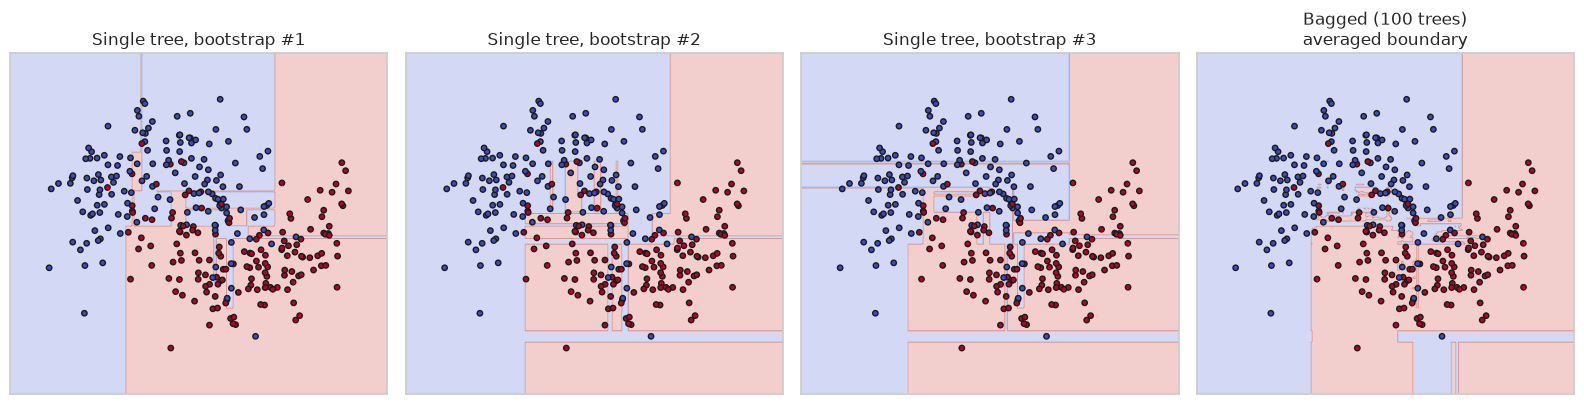

In [3]:
# Visualize *why* bagging helps: train several bootstrap trees on a 2D slice
# of the data and watch how much a single tree's boundary varies vs. the averaged boundary
from sklearn.datasets import make_moons

X2, y2 = make_moons(n_samples=300, noise=0.3, random_state=3)

def plot_boundary(model, ax, title, X_fit=X2, y_fit=y2):
    model.fit(X_fit, y_fit)
    x_min, x_max = X2[:, 0].min() - 0.5, X2[:, 0].max() + 0.5
    y_min, y_max = X2[:, 1].min() - 0.5, X2[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap="coolwarm")
    ax.scatter(X2[:, 0], X2[:, 1], c=y2, cmap="coolwarm", edgecolor="k", s=15)
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])

fig, axes = plt.subplots(1, 4, figsize=(16, 4.2))
for i, ax in enumerate(axes[:3]):
    boot_idx = rng.integers(0, len(X2), len(X2))
    plot_boundary(DecisionTreeClassifier(random_state=i), ax, f"Single tree, bootstrap #{i+1}",
                  X_fit=X2[boot_idx], y_fit=y2[boot_idx])
plot_boundary(BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=100, random_state=3),
              axes[3], "Bagged (100 trees)\naveraged boundary")
plt.tight_layout()
plt.show()

The first three panels are single trees on different bootstrap samples of
the *same* data — each draws a noticeably different, overfit boundary. The
last panel averages 100 such trees: the jagged, sample-specific quirks wash
out, leaving a smoother boundary that generalizes better.

## 2. Boosting: AdaBoost & Gradient Boosting

**Theory.** Boosting builds models **sequentially**, where each new (usually
weak) learner focuses on the mistakes of the ensemble so far:

- **AdaBoost** — re-weights training samples after each round, giving
  misclassified points more weight so the next weak learner focuses on them.
  Final prediction is a weighted vote across all learners.
- **Gradient Boosting** — each new tree fits the *residual errors* (negative
  gradient of the loss) of the current ensemble, and its output is added in.

Boosting mainly reduces **bias**, and can reach very high accuracy, but is
more prone to overfitting than bagging if run too long.

In [4]:
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier

adaboost = evaluate("AdaBoost (100 stumps)", AdaBoostClassifier(n_estimators=100, random_state=3))
gboost = evaluate("Gradient Boosting", GradientBoostingClassifier(n_estimators=200, max_depth=2, random_state=3))

       AdaBoost (100 stumps): accuracy=0.982  f1=0.986


           Gradient Boosting: accuracy=0.939  f1=0.951


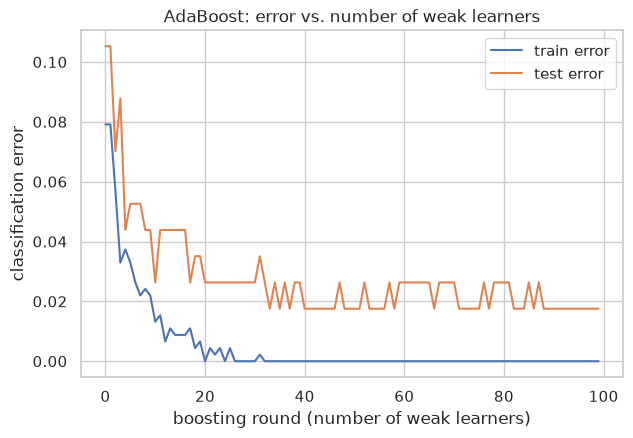

In [5]:
# Watch AdaBoost's test error fall as more weak learners are added
from sklearn.metrics import zero_one_loss

test_errors = [
    zero_one_loss(y_test, y_pred)
    for y_pred in adaboost.staged_predict(X_test_s)
]
train_errors = [
    zero_one_loss(y_train, y_pred)
    for y_pred in adaboost.staged_predict(X_train_s)
]

plt.figure(figsize=(7, 4.5))
plt.plot(train_errors, label="train error")
plt.plot(test_errors, label="test error")
plt.xlabel("boosting round (number of weak learners)")
plt.ylabel("classification error")
plt.title("AdaBoost: error vs. number of weak learners")
plt.legend()
plt.show()

Each individual "stump" (a depth-1 decision tree, barely better than a coin
flip alone) contributes a small weighted vote — together, hundreds of them
drive error down substantially. This is boosting's core trick: many weak
learners, combined smartly, make a strong one.

## 3. Voting Classifier

**Theory.** Combine predictions from **different types** of models (unlike
bagging/boosting, which reuse one base algorithm).

- **Hard voting** — majority vote on predicted class labels.
- **Soft voting** — average predicted probabilities, then take the argmax. Usually stronger, since it uses each model's confidence, not just its final answer.

Works best when the base models are individually decent but make **different
kinds** of errors (e.g., a linear model + a distance-based model + a
tree-based model).

In [6]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

base_estimators = [
    ("logreg", LogisticRegression(max_iter=5000)),
    ("knn", KNeighborsClassifier(n_neighbors=7)),
    ("rf", RandomForestClassifier(n_estimators=200, random_state=3)),
]

for name, model in base_estimators:
    evaluate(name, model)

evaluate("Voting (hard)", VotingClassifier(estimators=base_estimators, voting="hard"))
evaluate("Voting (soft)", VotingClassifier(estimators=base_estimators, voting="soft"))

                      logreg: accuracy=0.974  f1=0.979
                         knn: accuracy=0.974  f1=0.980


                          rf: accuracy=0.974  f1=0.979


               Voting (hard): accuracy=0.991  f1=0.993


               Voting (soft): accuracy=0.982  f1=0.986


,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('logreg', ...), ('knn', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[int64](2,)","[0,1]"
"estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators as defined in ``estimators``that are not 'drop'. Note that sub-estimators are always fitted oninteger-encoded labels (see ``le_`` attribute). When ``y`` containsnon-integer class labels (e.g. strings), use ``le_.inverse_transform``to map predictions back to the original label space.",list,"[LogisticRegre...max_iter=5000), KNeighborsCla...n_neighbors=7), RandomForestC...andom_state=3)]"
le_ le_: :class:`~sklearn.preprocessing.LabelEncoder`Transformer used to encode the labels during fit and decode duringprediction. Sub-estimators in ``estimators_`` are fitted on theinteger-encoded labels produced by this encoder.,LabelEncoder,LabelEncoder()
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying classifier exposes such an attribute when fit... versionadded:: 0.24,int,30


## 4. Stacking

**Theory.** Trains a **meta-learner** on top of the base models' *predictions*
(via cross-validation, to avoid leakage): instead of a fixed rule like
majority vote, the meta-learner learns how much to trust each base model,
and can combine them non-linearly.

In [7]:
from sklearn.ensemble import StackingClassifier

stacking = evaluate(
    "Stacking (meta=LogReg)",
    StackingClassifier(estimators=base_estimators, final_estimator=LogisticRegression(max_iter=5000), cv=5),
)

      Stacking (meta=LogReg): accuracy=0.991  f1=0.993


## 5. Ensemble Comparison

All methods, same breast-cancer split, same metrics.

,accuracy,f1
Voting (hard),0.991,0.993
Stacking (meta=LogReg),0.991,0.993
AdaBoost (100 stumps),0.982,0.986
Voting (soft),0.982,0.986
knn,0.974,0.980
Bagging (100 trees),0.974,0.979
rf,0.974,0.979
logreg,0.974,0.979
Gradient Boosting,0.939,0.951
Single Decision Tree,0.921,0.938


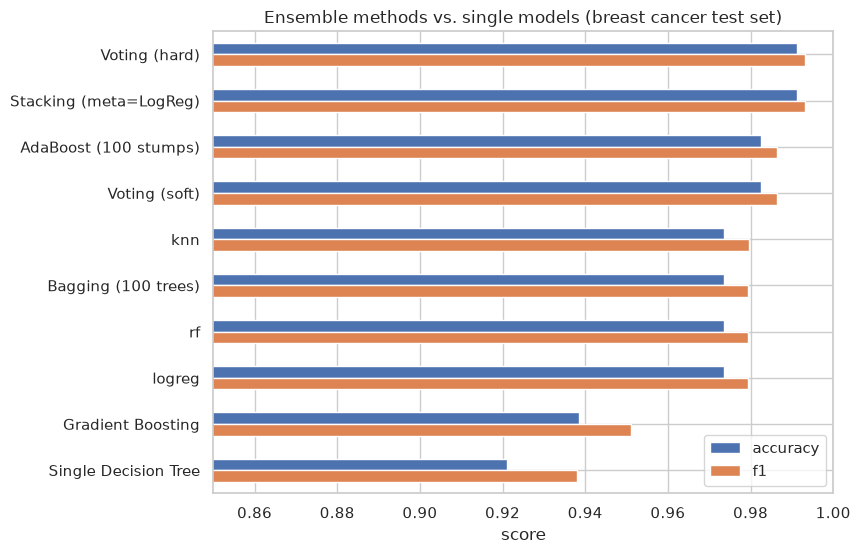

In [8]:
comparison = pd.DataFrame(results).T.sort_values("f1", ascending=False)
display(comparison.round(3))

comparison.plot.barh(figsize=(8, 6))
plt.gca().invert_yaxis()
plt.xlabel("score")
plt.title("Ensemble methods vs. single models (breast cancer test set)")
plt.xlim(0.85, 1.0)
plt.show()

## Exercises

1. Swap the `Bagging` base estimator from `DecisionTreeClassifier()` to `KNeighborsClassifier()` — does bagging still help as much? Why might bagging matter less for low-variance base learners?
2. In the Voting Classifier, remove the weakest individual base model and re-run — does soft voting's score change much?
3. Change the Stacking `final_estimator` to a `RandomForestClassifier` — does the meta-learner choice matter here?

## Key Takeaways

- **Bagging** (Random Forest included) mainly fights **variance** by averaging models trained on resampled data.
- **Boosting** (AdaBoost, Gradient Boosting) mainly fights **bias** by sequentially correcting mistakes, at higher overfitting risk if run too long.
- **Voting** and **Stacking** combine *different* model types — soft voting and stacking generally beat hard voting since they use confidence, not just the final label.
- Ensembles usually beat their best single component, but cost more compute and lose some interpretability — a tradeoff worth making explicitly.